In [42]:
import numpy as np
import pandas as pd
import mne 
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
mne.set_log_level('error')
import warnings
warnings.simplefilter("ignore")
import seaborn as sns

In [2]:
df = pd.read_csv('EEGdata.csv')
df

,Time,FZ,C3,CZ,C4,PZ,PO7,OZ,PO8,AccX,AccY,AccZ,Gyro1,Gyro2,Gyro3,Battery,Counter,Validation
0,471108.629297,259145.062500,255463.203125,280156.78125,297592.40625,268555.25000,255108.156250,232334.953125,239896.906250,-0.156006,0.782959,-0.566162,-10.437011,6.835937,13.610839,93.333344,405287.0,1.0
1,471108.634537,259071.937500,255626.625000,282968.28125,297913.18750,269795.59375,255109.765625,232506.515625,240036.203125,-0.143799,0.778809,-0.562500,-9.582519,6.866455,13.305663,93.333344,405288.0,1.0
2,471108.634549,259450.296875,255598.296875,283131.25000,297802.50000,269435.43750,255080.796875,232323.593750,239907.625000,-0.137451,0.773926,-0.560303,-9.185790,7.019042,13.183593,93.333344,405289.0,1.0
3,471108.636824,259770.734375,255431.093750,280456.65625,297436.09375,267998.68750,255079.453125,232064.765625,239711.656250,-0.133545,0.770508,-0.560303,-8.483886,7.385253,12.847899,93.333344,405290.0,1.0
4,471108.639355,259562.062500,255346.515625,278669.31250,297312.09375,267488.87500,255097.703125,232085.765625,239713.000000,-0.132324,0.774902,-0.561523,-7.568359,7.873535,12.390136,93.333344,405291.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22495,471198.551129,258254.125000,254949.640625,279801.21875,295778.25000,268732.00000,254846.203125,232013.718750,238981.109375,-0.112061,0.844971,-0.537354,-0.366211,1.525879,1.220703,93.333344,427782.0,1.0
22496,471198.553541,258417.921875,255122.828125,281468.75000,295981.37500,269351.40625,254852.453125,232079.421875,239042.890625,-0.112549,0.842041,-0.536865,-0.305176,1.434326,1.220703,93.333344,427783.0,1.0
22497,471198.553577,259169.203125,255450.406250,281751.81250,295821.40625,269106.87500,254874.625000,231927.250000,238939.890625,-0.112793,0.843262,-0.536377,-0.335693,1.403808,1.342773,93.333344,427784.0,1.0
22498,471198.556081,259407.296875,255442.984375,280239.21875,295526.37500,268337.25000,254880.078125,231773.296875,238814.281250,-0.109863,0.843994,-0.535156,-0.396728,1.373291,1.342773,93.333344,427785.0,1.0


In [3]:
events_array = df['Validation']
df = df.drop(columns = ['Time','Battery','Counter'])
EEG_data = df.values.T * 1e-6  # Convert μV to Volts
ch_names = df.columns[0:8].tolist()
ch_types = ['eeg']*len(ch_names)

In [4]:
df

,FZ,C3,CZ,C4,PZ,PO7,OZ,PO8,AccX,AccY,AccZ,Gyro1,Gyro2,Gyro3,Validation
0,259145.062500,255463.203125,280156.78125,297592.40625,268555.25000,255108.156250,232334.953125,239896.906250,-0.156006,0.782959,-0.566162,-10.437011,6.835937,13.610839,1.0
1,259071.937500,255626.625000,282968.28125,297913.18750,269795.59375,255109.765625,232506.515625,240036.203125,-0.143799,0.778809,-0.562500,-9.582519,6.866455,13.305663,1.0
2,259450.296875,255598.296875,283131.25000,297802.50000,269435.43750,255080.796875,232323.593750,239907.625000,-0.137451,0.773926,-0.560303,-9.185790,7.019042,13.183593,1.0
3,259770.734375,255431.093750,280456.65625,297436.09375,267998.68750,255079.453125,232064.765625,239711.656250,-0.133545,0.770508,-0.560303,-8.483886,7.385253,12.847899,1.0
4,259562.062500,255346.515625,278669.31250,297312.09375,267488.87500,255097.703125,232085.765625,239713.000000,-0.132324,0.774902,-0.561523,-7.568359,7.873535,12.390136,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22495,258254.125000,254949.640625,279801.21875,295778.25000,268732.00000,254846.203125,232013.718750,238981.109375,-0.112061,0.844971,-0.537354,-0.366211,1.525879,1.220703,1.0
22496,258417.921875,255122.828125,281468.75000,295981.37500,269351.40625,254852.453125,232079.421875,239042.890625,-0.112549,0.842041,-0.536865,-0.305176,1.434326,1.220703,1.0
22497,259169.203125,255450.406250,281751.81250,295821.40625,269106.87500,254874.625000,231927.250000,238939.890625,-0.112793,0.843262,-0.536377,-0.335693,1.403808,1.342773,1.0
22498,259407.296875,255442.984375,280239.21875,295526.37500,268337.25000,254880.078125,231773.296875,238814.281250,-0.109863,0.843994,-0.535156,-0.396728,1.373291,1.342773,1.0


In [5]:
info = mne.create_info(ch_names = ch_names, ch_types = ch_types, sfreq = 250)
raw = mne.io.RawArray(EEG_data[0:8], info)
raw

<RawArray | 8 x 22500 (90.0 s), ~1.4 MiB, data loaded>

In [6]:
raw.describe()

<RawArray | 8 x 22500 (90.0 s), ~1.4 MiB, data loaded>
ch  name  type  unit        min         Q1     median         Q3        max
 0  FZ    EEG   µV    258186.17  258779.37  259110.16  259337.83  259782.62
 1  C3    EEG   µV    254641.19  255149.62  255247.55  255438.27  255750.28
 2  CZ    EEG   µV    276033.88  279648.48  280666.67  282058.84  284657.62
 3  C4    EEG   µV    295350.25  296175.10  296616.55  297078.41  297941.00
 4  PZ    EEG   µV    266834.34  268176.06  268638.08  269376.92  270314.69
 5  PO7   EEG   µV    254586.30  254895.55  254931.62  254963.95  255142.77
 6  OZ    EEG   µV    231668.16  231855.38  232014.78  232102.67  232609.78
 7  PO8   EEG   µV    238791.30  239002.39  239124.70  239290.30  240071.78


In [7]:
raw.info['dig']

In [8]:
raw.info['ch_names']

['FZ', 'C3', 'CZ', 'C4', 'PZ', 'PO7', 'OZ', 'PO8']

In [9]:
mapping = {
    'FZ': 'Fz',
    'CZ': 'Cz',
    'C3': 'C3',
    'C4': 'C4',
    'PZ': 'Pz',
    'PO7': 'PO7',
    'OZ': 'Oz',
    'PO8': 'PO8'
}

raw.rename_channels(mapping)


<RawArray | 8 x 22500 (90.0 s), ~1.4 MiB, data loaded>

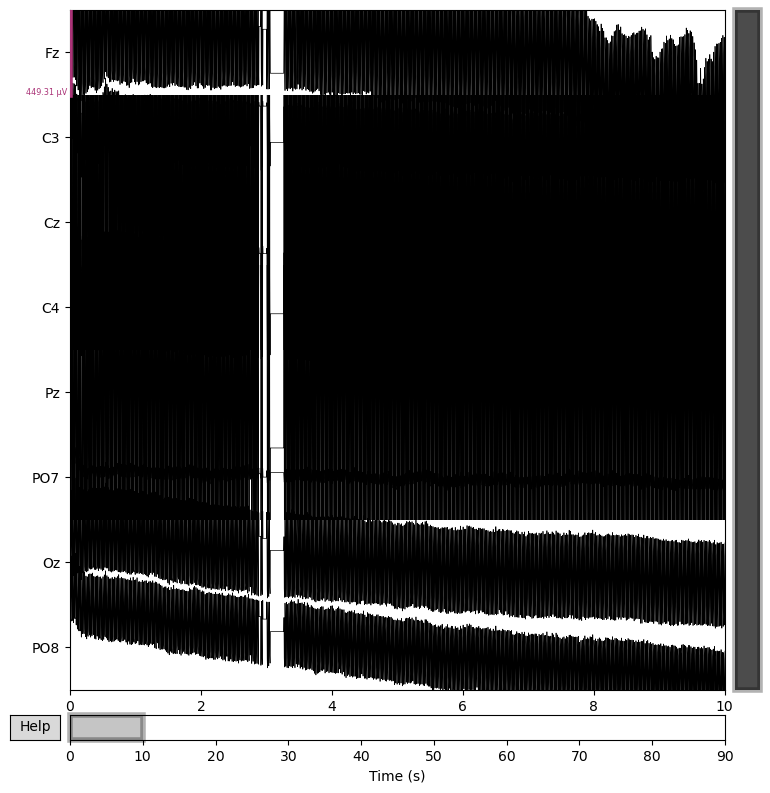

In [10]:
picks = mne.pick_channels_regexp(raw.ch_names, regexp="['FZ', 'C3', 'CZ', 'C4', 'PZ', 'PO7', 'OZ', 'PO8']")
raw.plot(order=picks, n_channels=len(picks), scalings = 'auto');

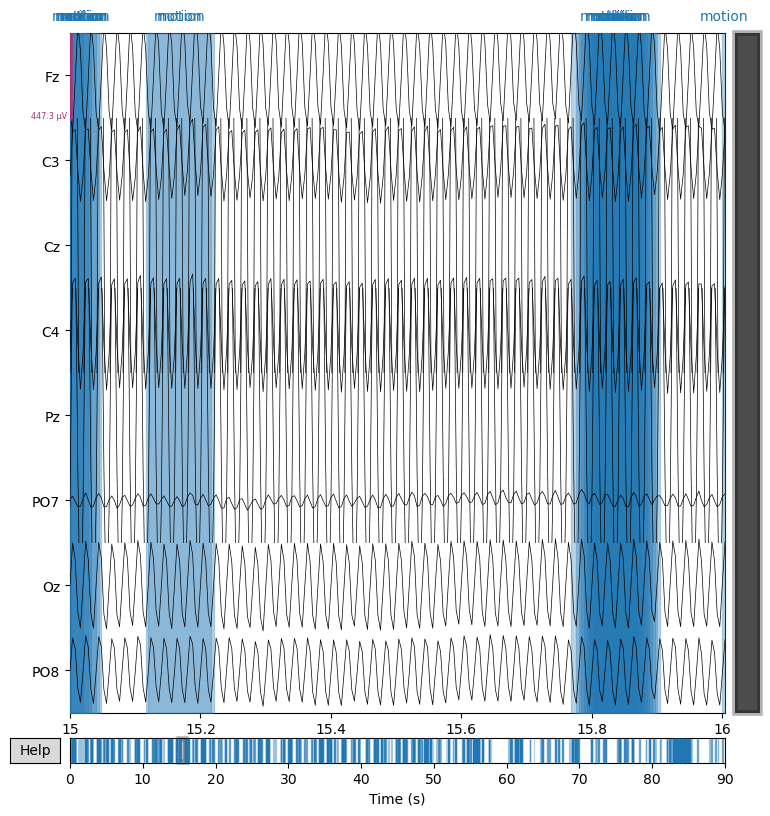

In [27]:
raw.plot(start = 15, duration = 1, scalings = "auto");

In [11]:
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage)

<RawArray | 8 x 22500 (90.0 s), ~1.4 MiB, data loaded>

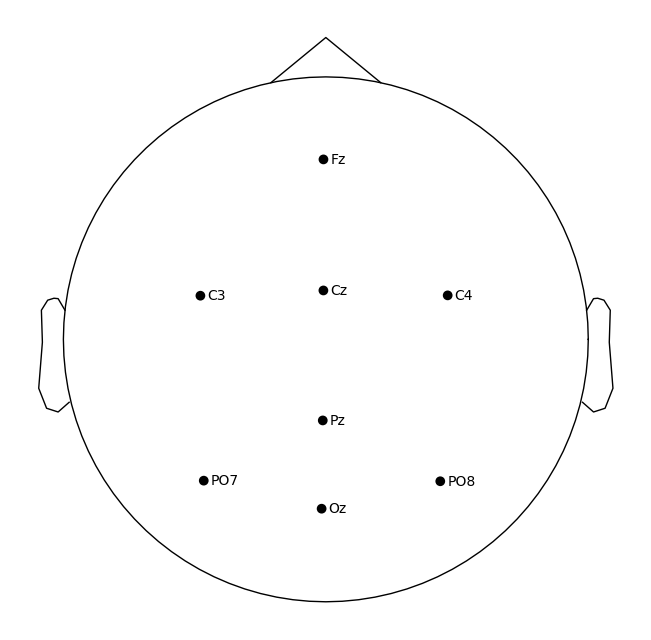

In [12]:
raw.plot_sensors(show_names = True)
plt.show()

# Motor Imagery(MI)

Channel selection: C3, C4, Cz, Fz, accelerometer norm, gyroscope norm, and the validation signal.

In [13]:
df.columns = df.columns.str.strip()

# Accelerometer norm
df['Acc_norm'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)

# Gyroscope norm
df['Gyro_norm'] = np.sqrt(df['Gyro1']**2 + df['Gyro2']**2 + df['Gyro3']**2)


In [14]:
# Step 3: Set thresholds
# -------------------------------
acc_threshold = df['Acc_norm'].quantile(0.95)
gyro_threshold = df['Gyro_norm'].quantile(0.95)


In [15]:
# Step 4: Filter segments
# -------------------------------
high_acc = df[df['Acc_norm'] > acc_threshold]
high_gyro = df[df['Gyro_norm'] > gyro_threshold]
val_1 = df[df['Validation'] == 1]
val_0 = df[df['Validation'] == 0]


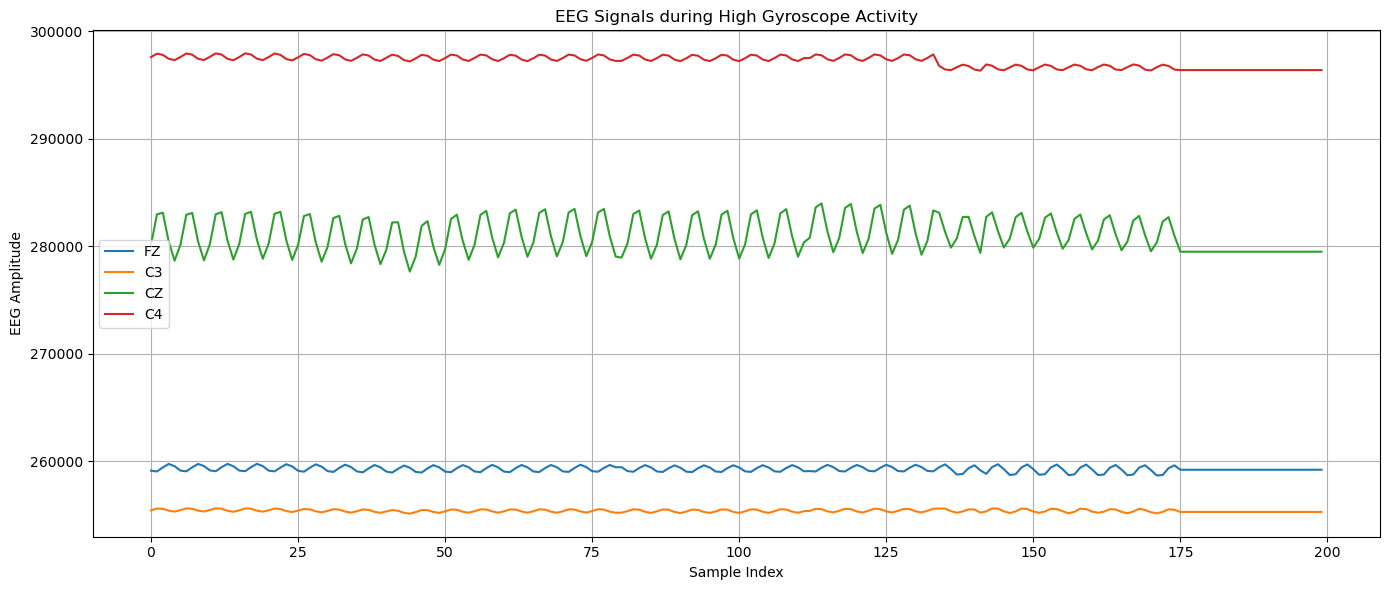

In [16]:
# Step 5: Visualize EEG signals with high gyro
# -------------------------------
plt.figure(figsize=(14, 6))
for ch in ['FZ', 'C3', 'CZ', 'C4']:
    plt.plot(high_gyro[ch].values[:200], label=ch)
plt.title("EEG Signals during High Gyroscope Activity")
plt.xlabel("Sample Index")
plt.ylabel("EEG Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

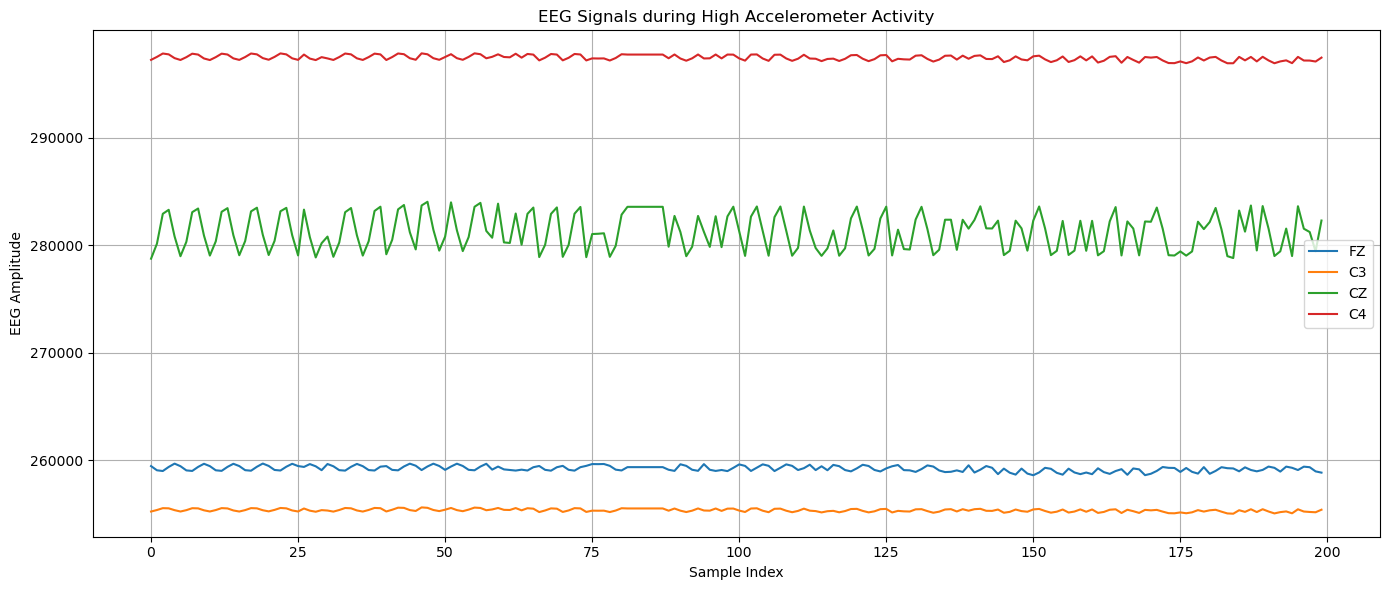

In [17]:
# Step 6: Visualize EEG signals with high accelerometer
# -------------------------------
plt.figure(figsize=(14, 6))
for ch in ['FZ', 'C3', 'CZ', 'C4']:
    plt.plot(high_acc[ch].values[:200], label=ch)
plt.title("EEG Signals during High Accelerometer Activity")
plt.xlabel("Sample Index")
plt.ylabel("EEG Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
# Step 7: Compare Validation == 1 vs 0
# -------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

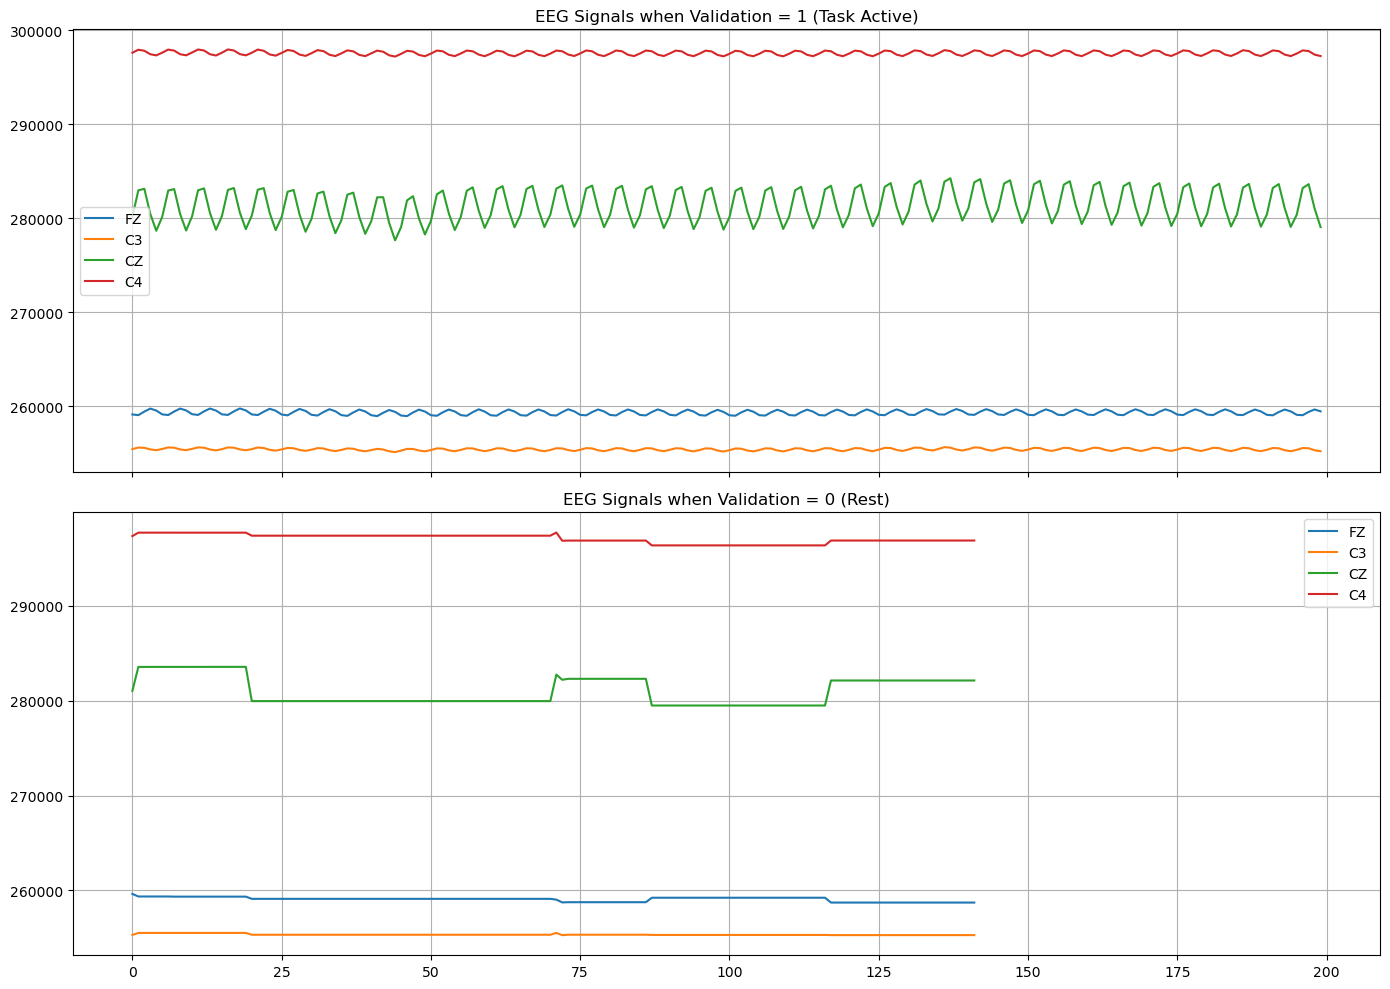

In [19]:
# Validation = 1
for ch in ['FZ', 'C3', 'CZ', 'C4']:
    axes[0].plot(val_1[ch].values[:200], label=ch)
axes[0].set_title("EEG Signals when Validation = 1 (Task Active)")
axes[0].legend()
axes[0].grid(True)

# Validation = 0
for ch in ['FZ', 'C3', 'CZ', 'C4']:
    axes[1].plot(val_0[ch].values[:200], label=ch)
axes[1].set_title("EEG Signals when Validation = 0 (Rest)")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

In [20]:
# Summary statistics for selected EEG channels
eeg_channels = ['FZ', 'C3', 'CZ', 'C4']
print("Summary Stats:\n", df[eeg_channels].describe())

Summary Stats:
                   FZ             C3             CZ             C4
count   22500.000000   22500.000000   22500.000000   22500.000000
mean   259043.373226  255272.260108  280880.622412  296624.994668
std       357.563261     167.205843    1494.989381     559.671717
min    258186.171875  254641.187500  276033.875000  295350.250000
25%    258779.367188  255149.621094  279648.484375  296175.101562
50%    259110.156250  255247.546875  280666.671875  296616.546875
75%    259337.828125  255438.273438  282058.835938  297078.406250
max    259782.625000  255750.281250  284657.625000  297941.000000


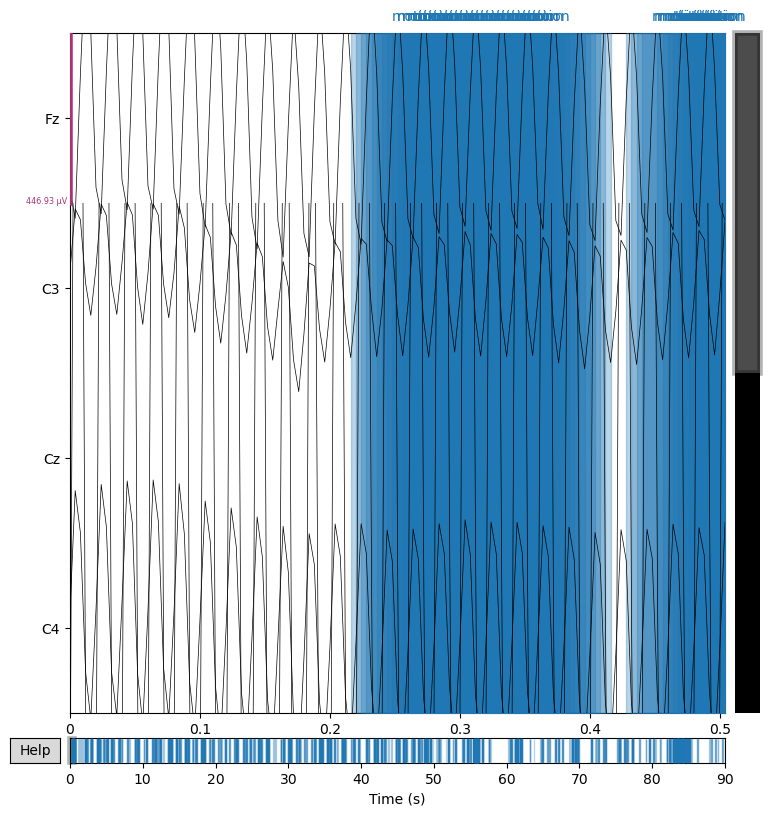

In [29]:
raw.plot(n_channels=4, duration=0.5, scalings='auto', title='Butterfly EEG View');


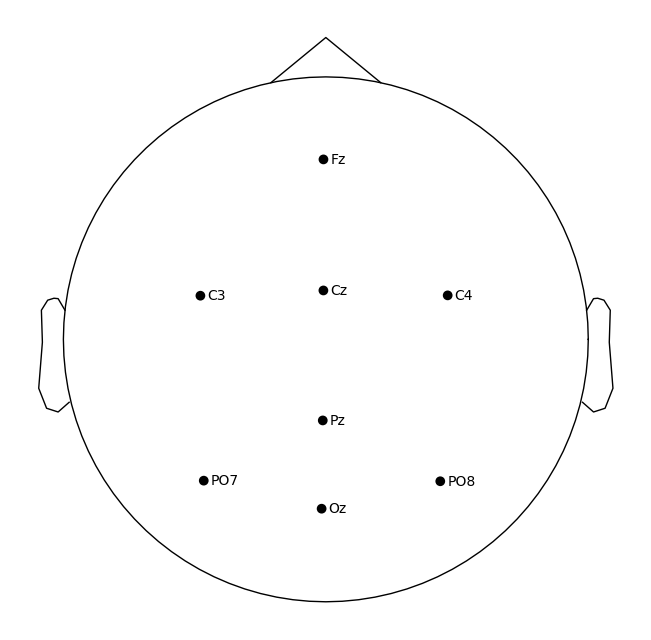

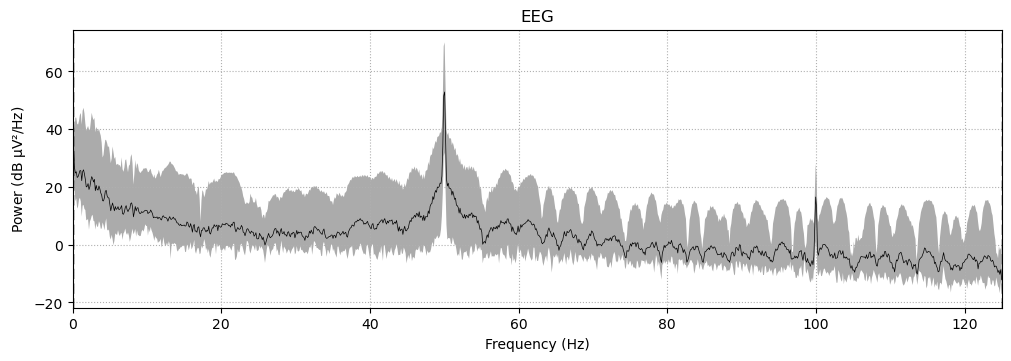

In [22]:
# Pick a timepoint in seconds (e.g., 1s)
raw.plot_sensors(show_names=True, kind='topomap', title='Electrode Positions')
raw.plot_psd(area_mode='range', average=True)  # Frequency domain


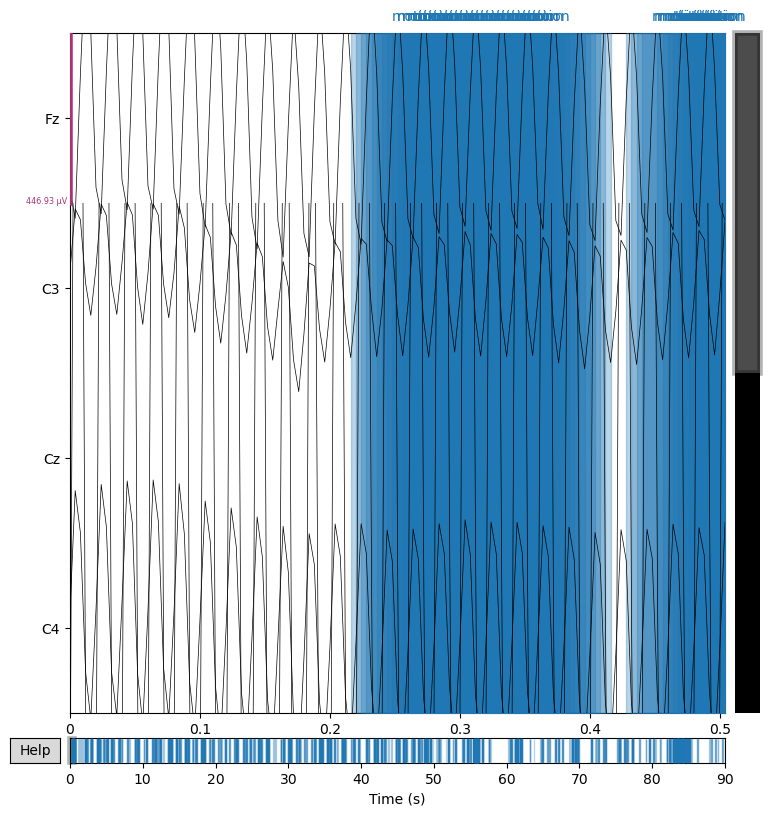

In [30]:
# Step 7: Add accelerometer & gyroscope as annotations (optional advanced)
# ------------------------------------------------
# Create MNE annotations for motion (e.g., high acc)
df['Acc_norm'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)
acc_threshold = df['Acc_norm'].quantile(0.95)
motion_indices = df.index[df['Acc_norm'] > acc_threshold].tolist()

onset_times = [i / 250 for i in motion_indices]
durations = [0.1] * len(onset_times)  # 100ms segments
descriptions = ['motion'] * len(onset_times)
annotations = mne.Annotations(onset=onset_times, duration=durations, description=descriptions)
raw.set_annotations(annotations)

# Plot again with motion highlighted
raw.plot(n_channels=4, duration=.5, scalings='auto', title='With Motion Annotations');


# Filtration

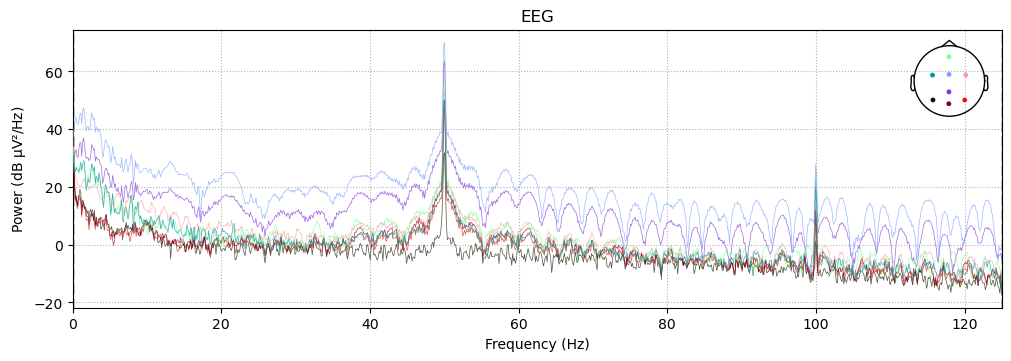

In [53]:
psd = raw.compute_psd()
psd.plot()
plt.show()

In [54]:
raw_filtered = raw.copy().filter(l_freq=8, h_freq=14)

raw_filtered.notch_filter(freqs=50)

<RawArray | 8 x 22500 (90.0 s), ~1.4 MiB, data loaded>

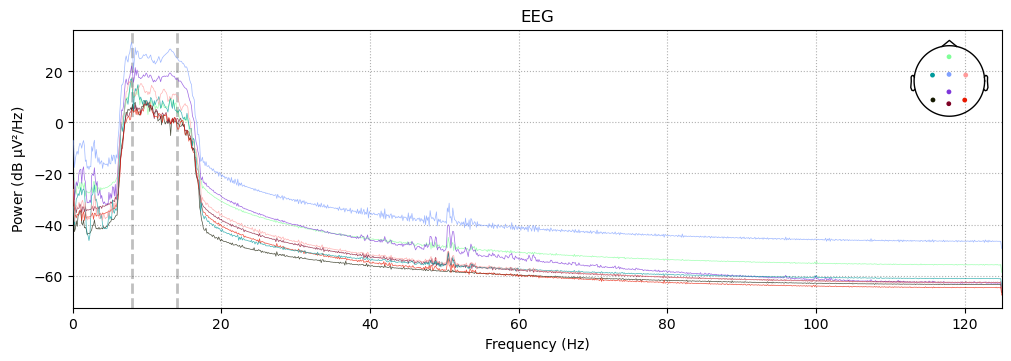

In [56]:
raw_filtered.compute_psd().plot()

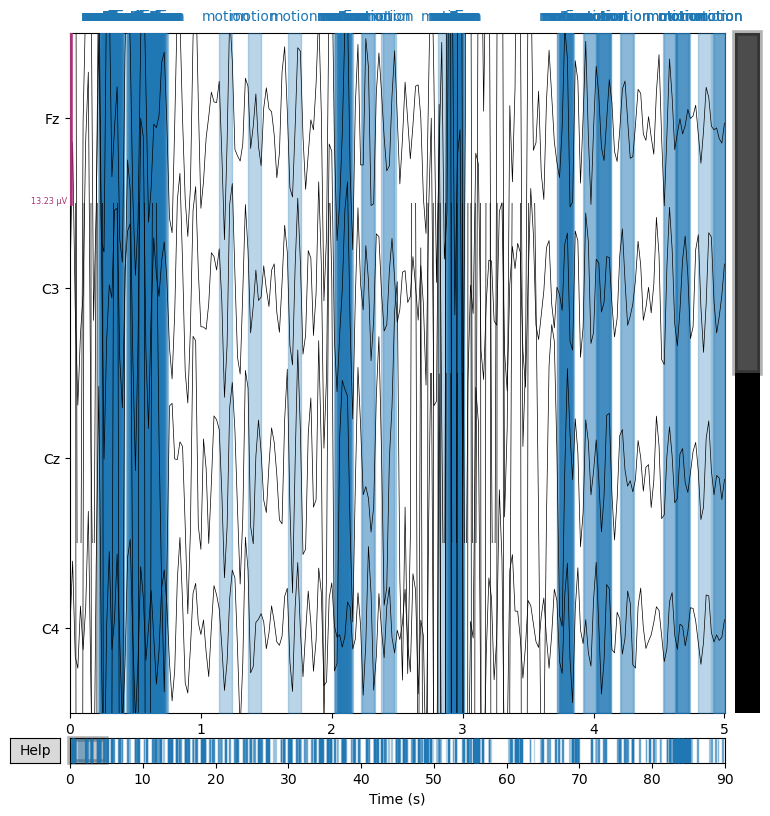

In [58]:

# Plot EEG After Filtering
# -------------------------------
raw_filtered.plot(n_channels=4, duration=5, scalings='auto', title="EEG After Filtering");


In [43]:
def lowpass_filter(data, cutoff=5, fs=250, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)


In [47]:
# Filter Acc and Gyro signals
for sensor in ['AccX', 'AccY', 'AccZ', 'Gyro1', 'Gyro2', 'Gyro3']:
    df[f'{sensor}_filtered'] = lowpass_filter(df[sensor], cutoff=5, fs=250)

# --------------------------------------
# Step 4: Recalculate norms
# --------------------------------------
df['Acc_norm'] = np.sqrt(
    df['AccX_filtered']**2 + df['AccY_filtered']**2 + df['AccZ_filtered']**2
)
df['Gyro_norm'] = np.sqrt(
    df['Gyro1_filtered']**2 + df['Gyro2_filtered']**2 + df['Gyro3_filtered']**2
)


<Figure size 1200x400 with 0 Axes>

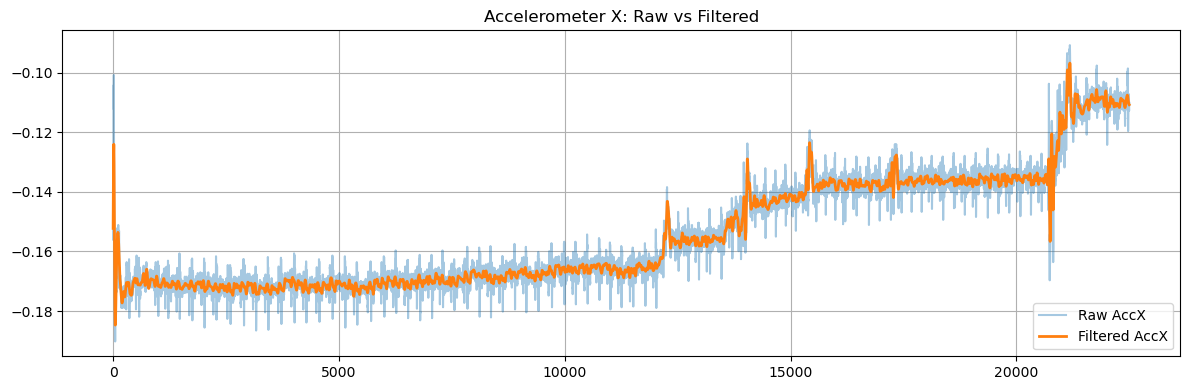

In [49]:
# Step 5: Plot comparison before/after
# --------------------------------------
plt.figure(figsize=(12, 4))
plt.plot(df['AccX'], label='Raw AccX', alpha=0.4)
plt.plot(df['AccX_filtered'], label='Filtered AccX', linewidth=2)
plt.title("Accelerometer X: Raw vs Filtered")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

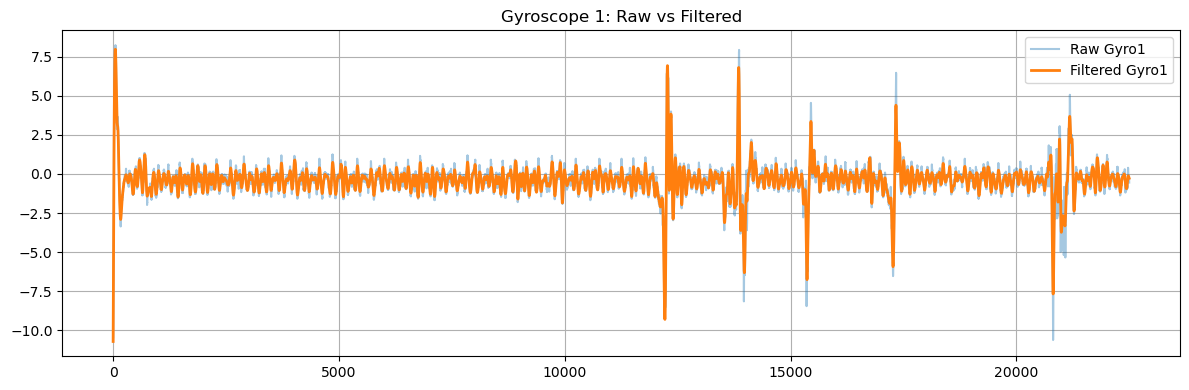

In [50]:
plt.figure(figsize=(12, 4))
plt.plot(df['Gyro1'], label='Raw Gyro1', alpha=0.4)
plt.plot(df['Gyro1_filtered'], label='Filtered Gyro1', linewidth=2)
plt.title("Gyroscope 1: Raw vs Filtered")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# SSVEP

Channel selection: OZ, PO7, PO8, PZ, accelerometer norm, gyroscope norm, and the validation signal.

In [61]:
ssvep_df  = pd.read_csv('EEGdata2.csv')
ssvep_df 

,Time,FZ,C3,CZ,C4,PZ,PO7,OZ,PO8,AccX,AccY,AccZ,Gyro1,Gyro2,Gyro3,Battery,Counter,Validation
0,469033.913193,258287.656250,264789.31250,280744.62500,264021.84375,258592.968750,255182.093750,229271.875000,245442.546875,-0.113525,0.828857,-0.555664,-0.701904,1.708984,0.732422,100.0,66617.0,1.0
1,469033.913220,259057.625000,264991.46875,279824.28125,263310.53125,257506.234375,255150.187500,228774.937500,245187.656250,-0.114990,0.828613,-0.558594,-0.671387,1.708984,0.823975,100.0,66618.0,1.0
2,469033.913222,259117.703125,264636.09375,276138.75000,262477.34375,255673.484375,255143.203125,228390.046875,245012.593750,-0.114990,0.827148,-0.558594,-0.579834,1.861572,0.823975,100.0,66619.0,1.0
3,469033.913224,258451.265625,264274.34375,274926.75000,262635.34375,255619.656250,255160.015625,228623.937500,245139.734375,-0.114258,0.827881,-0.561523,-0.457764,1.800537,0.854492,100.0,66620.0,1.0
4,469033.915669,257968.921875,264438.06250,278104.53125,263602.71875,257495.062500,255195.515625,229186.578125,245414.484375,-0.113281,0.825439,-0.561279,-0.335693,1.800537,0.793457,100.0,66621.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17495,469103.789898,259786.828125,263683.62500,277704.62500,265236.37500,260460.234375,258308.578125,224980.250000,247020.500000,-0.115967,0.835938,-0.562012,-0.061035,1.373291,0.274658,100.0,84112.0,1.0
17496,469103.790996,260592.921875,263896.87500,275307.34375,264623.37500,258985.562500,258315.015625,224634.234375,246845.437500,-0.113037,0.836182,-0.562744,-0.091553,1.373291,0.274658,100.0,84113.0,1.0
17497,469103.792266,260513.078125,263728.78125,272914.90625,264451.28125,258225.156250,258334.765625,224621.453125,246855.093750,-0.113525,0.834961,-0.562744,-0.213623,1.403808,0.335693,100.0,84114.0,1.0
17498,469103.812515,259707.531250,263451.00000,273780.37500,264930.06250,259186.906250,258330.656250,224941.343750,247020.218750,-0.113525,0.829834,-0.562012,-0.244141,1.403808,0.549316,100.0,84115.0,1.0


In [78]:
events_array = ssvep_df['Validation']
ssvep_df = ssvep_df.drop(columns = ['Time','Battery','Counter'])
EEG_data = ssvep_df.values.T * 1e-6  # Convert μV to Volts
ch_names = ssvep_df.columns[0:8].tolist()
ch_types = ['eeg']*len(ch_names)

KeyError: "['Time', 'Battery', 'Counter'] not found in axis"

In [ ]:
ssvep_df

In [ ]:
info = mne.create_info(ch_names = ch_names, ch_types = ch_types, sfreq = 250)
raw = mne.io.RawArray(EEG_data[0:8], info)
raw

In [ ]:
raw.info['dig']

In [ ]:
# Accelerometer norm
df['Acc_norm'] = np.sqrt(df['AccX']**2 + df['AccY']**2 + df['AccZ']**2)

# Gyroscope norm
df['Gyro_norm'] = np.sqrt(df['Gyro1']**2 + df['Gyro2']**2 + df['Gyro3']**2)


In [ ]:
# Step 5: Visualize EEG signals with high gyro
# -------------------------------
plt.figure(figsize=(14, 6))
for ch in ['OZ', 'PO7', 'PO8', 'PZ']:
    plt.plot(high_gyro[ch].values[:200], label=ch)
plt.title("EEG Signals during High Gyroscope Activity")
plt.xlabel("Sample Index")
plt.ylabel("EEG Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Step 7: Compare Validation == 1 vs 0
# -------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

In [ ]:
# Validation = 1
for ch in ['OZ', 'PO7', 'PO8', 'PZ']:
    axes[0].plot(val_1[ch].values[:200], label=ch)
axes[0].set_title("EEG Signals when Validation = 1 (Task Active)")
axes[0].legend()
axes[0].grid(True)

# Validation = 0
for ch in ['OZ', 'PO7', 'PO8', 'PZ']:
    axes[1].plot(val_0[ch].values[:200], label=ch)
axes[1].set_title("EEG Signals when Validation = 0 (Rest)")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

In [ ]:
raw.plot(n_channels=4, duration=0.5, scalings='auto', title='Butterfly EEG View');


In [ ]:
psd = raw.compute_psd()
psd.plot()
plt.show()

In [ ]:
raw_filtered = raw.copy().filter(l_freq=8, h_freq=14)

raw_filtered.notch_filter(freqs=50)

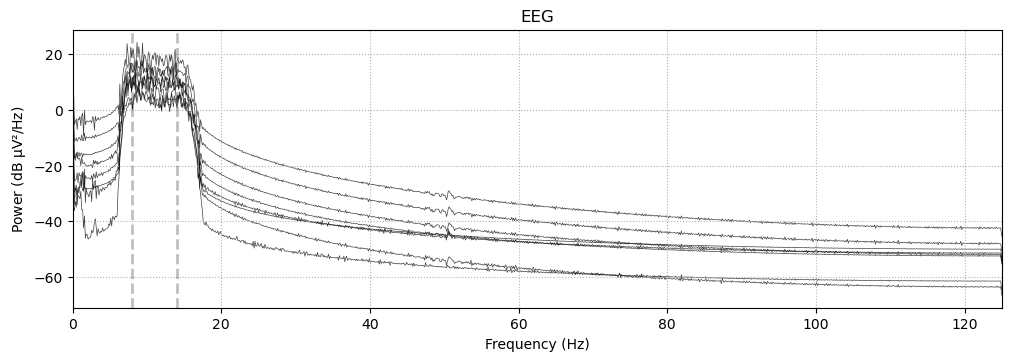

In [89]:
raw_filtered.compute_psd().plot()

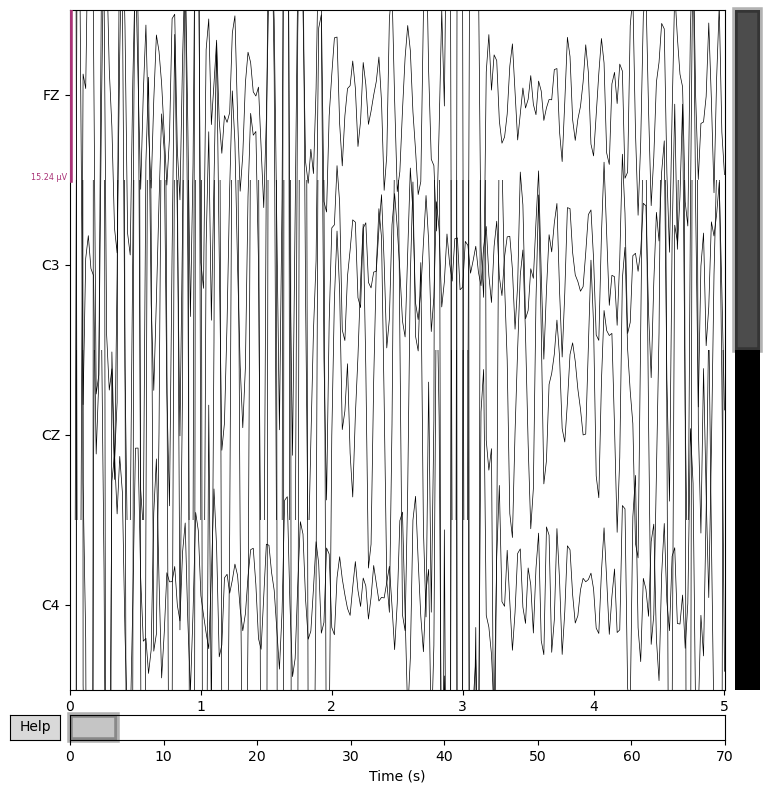

In [91]:

# Plot EEG After Filtering
# -------------------------------
raw_filtered.plot(n_channels=4, duration=5, scalings='auto', title="EEG After Filtering");
